In [56]:
import pandas as pd
import numpy as np

In [57]:
df = pd.read_csv("netflix_titles.csv")

In [58]:
print(df.head())
print(df.info())
print(df.describe())
print(df.shape)

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [59]:
print(df.dtypes)

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object


In [60]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [61]:
missing = df.isnull().sum() / len(df) * 100
print(missing.sort_values(ascending=False))

director        29.908028
country          9.435676
cast             9.367549
date_added       0.113546
rating           0.045418
duration         0.034064
show_id          0.000000
type             0.000000
title            0.000000
release_year     0.000000
listed_in        0.000000
description      0.000000
dtype: float64


In [62]:
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

0


In [63]:
df["director"] = df["director"].fillna("Unknown")

In [64]:
df["country"] = df["country"].fillna("Unknown")

In [65]:
df.dropna(subset=["date_added"], inplace=True)

In [66]:
print(df["date_added"].dtype)

str


In [67]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [68]:
df["date_added"].isna().sum()

np.int64(88)

In [69]:
df[df["date_added"].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
6079,s6080,TV Show,Abnormal Summit,"Jung-ah Im, Seung-uk Jo","Hyun-moo Jun, Si-kyung Sung, Se-yoon Yoo",South Korea,NaT,2017,TV-PG,2 Seasons,"International TV Shows, Korean TV Shows, Stand...","Led by a trio of Korean celebs, a multinationa..."
6177,s6178,TV Show,忍者ハットリくん,Unknown,NaN,Japan,NaT,2012,TV-Y7,2 Seasons,"Anime Series, Kids' TV","Hailing from the mountains of Iga, Kanzo Hatto..."
6213,s6214,TV Show,Bad Education,Unknown,"Jack Whitehall, Mathew Horne, Sarah Solemani, ...",United Kingdom,NaT,2014,TV-MA,3 Seasons,"British TV Shows, TV Comedies","A history teacher at the posh Abbey Grove, Alf..."
6279,s6280,TV Show,Being Mary Jane: The Series,Unknown,"Gabrielle Union, Lisa Vidal, Margaret Avery, O...",United States,NaT,2016,TV-14,4 Seasons,"Romantic TV Shows, TV Dramas",Ambitious single TV journalist Mary Jane attem...
6304,s6305,TV Show,"Big Dreams, Small Spaces",Unknown,Monty Don,United Kingdom,NaT,2017,TV-G,3 Seasons,"British TV Shows, International TV Shows, Real...",Writer and presenter Monty Don helps England's...
...,...,...,...,...,...,...,...,...,...,...,...,...
8539,s8540,TV Show,The Tudors,Unknown,"Jonathan Rhys Meyers, Henry Cavill, James Frai...","Ireland, Canada, United States, United Kingdom",NaT,2010,TV-MA,4 Seasons,TV Dramas,All the splendor and scandal of England's 16th...
8557,s8558,TV Show,The West Wing,Unknown,"Martin Sheen, Rob Lowe, Allison Janney, John S...",United States,NaT,2005,TV-14,7 Seasons,TV Dramas,This powerful political epic chronicles the tr...
8684,s8685,TV Show,Vroomiz,Unknown,"Joon-seok Song, Jeong-hwa Yang, Sang-hyun Um, ...",South Korea,NaT,2016,TV-Y,3 Seasons,"Kids' TV, Korean TV Shows","For these half-car, half-animal friends, each ..."
8712,s8713,TV Show,Weird Wonders of the World,Unknown,Chris Packham,United Kingdom,NaT,2016,TV-PG,2 Seasons,"British TV Shows, Docuseries, Science & Nature TV",From animal oddities and bizarre science to me...


In [70]:
df["date_added"] = pd.to_datetime(
    df["date_added"].astype(str).str.strip(),
    errors="coerce"
)

In [71]:
print(df["date_added"].dtype)

datetime64[us]


In [72]:
df["date_added"].isna().sum() / len(df) * 100


np.float64(1.000341025349551)

In [73]:
missing_count = df["date_added"].isna().sum()
missing_percent = missing_count / len(df) * 100

print("Brakujące daty:", missing_count)
print("Procent braków:", round(missing_percent, 2), "%")

Brakujące daty: 88
Procent braków: 1.0 %


In [74]:
df[df["date_added"].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
6079,s6080,TV Show,Abnormal Summit,"Jung-ah Im, Seung-uk Jo","Hyun-moo Jun, Si-kyung Sung, Se-yoon Yoo",South Korea,NaT,2017,TV-PG,2 Seasons,"International TV Shows, Korean TV Shows, Stand...","Led by a trio of Korean celebs, a multinationa..."
6177,s6178,TV Show,忍者ハットリくん,Unknown,NaN,Japan,NaT,2012,TV-Y7,2 Seasons,"Anime Series, Kids' TV","Hailing from the mountains of Iga, Kanzo Hatto..."
6213,s6214,TV Show,Bad Education,Unknown,"Jack Whitehall, Mathew Horne, Sarah Solemani, ...",United Kingdom,NaT,2014,TV-MA,3 Seasons,"British TV Shows, TV Comedies","A history teacher at the posh Abbey Grove, Alf..."
6279,s6280,TV Show,Being Mary Jane: The Series,Unknown,"Gabrielle Union, Lisa Vidal, Margaret Avery, O...",United States,NaT,2016,TV-14,4 Seasons,"Romantic TV Shows, TV Dramas",Ambitious single TV journalist Mary Jane attem...
6304,s6305,TV Show,"Big Dreams, Small Spaces",Unknown,Monty Don,United Kingdom,NaT,2017,TV-G,3 Seasons,"British TV Shows, International TV Shows, Real...",Writer and presenter Monty Don helps England's...
...,...,...,...,...,...,...,...,...,...,...,...,...
8539,s8540,TV Show,The Tudors,Unknown,"Jonathan Rhys Meyers, Henry Cavill, James Frai...","Ireland, Canada, United States, United Kingdom",NaT,2010,TV-MA,4 Seasons,TV Dramas,All the splendor and scandal of England's 16th...
8557,s8558,TV Show,The West Wing,Unknown,"Martin Sheen, Rob Lowe, Allison Janney, John S...",United States,NaT,2005,TV-14,7 Seasons,TV Dramas,This powerful political epic chronicles the tr...
8684,s8685,TV Show,Vroomiz,Unknown,"Joon-seok Song, Jeong-hwa Yang, Sang-hyun Um, ...",South Korea,NaT,2016,TV-Y,3 Seasons,"Kids' TV, Korean TV Shows","For these half-car, half-animal friends, each ..."
8712,s8713,TV Show,Weird Wonders of the World,Unknown,Chris Packham,United Kingdom,NaT,2016,TV-PG,2 Seasons,"British TV Shows, Docuseries, Science & Nature TV",From animal oddities and bizarre science to me...


In [75]:
df.loc[df["date_added"].isna(), "date_added"]

6079   NaT
6177   NaT
6213   NaT
6279   NaT
6304   NaT
        ..
8539   NaT
8557   NaT
8684   NaT
8712   NaT
8755   NaT
Name: date_added, Length: 88, dtype: datetime64[us]

In [76]:
df["date_added_raw"] = df["date_added"]

df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

df[df["date_added"].isna()][["date_added_raw"]]

,date_added_raw
6079,NaT
6177,NaT
6213,NaT
6279,NaT
6304,NaT
...,...
8539,NaT
8557,NaT
8684,NaT
8712,NaT


In [77]:
print("Analiza date_added zakończona – brakujące wartości pozostawiono bez imputacji")


Analiza date_added zakończona – brakujące wartości pozostawiono bez imputacji


Analiza i czyszczenie kolumny 'cast'

In [78]:
print("Brakujące wartości w kolumnie cast:")
print(df["cast"].isnull().sum())

Brakujące wartości w kolumnie cast:
825


In [79]:
df.loc[df["cast"].isna(), ["title", "director", "cast"]]

,title,director,cast
0,Dick Johnson Is Dead,Kirsten Johnson,NaN
3,Jailbirds New Orleans,Unknown,NaN
10,"Vendetta: Truth, Lies and The Mafia",Unknown,NaN
14,Crime Stories: India Detectives,Unknown,NaN
16,Europe's Most Dangerous Man: Otto Skorzeny in ...,"Pedro de Echave García, Pablo Azorín Williams",NaN
...,...,...,...
8746,Winnie,Pascale Lamche,NaN
8755,Women Behind Bars,Unknown,NaN
8756,Woodstock,Barak Goodman,NaN
8763,WWII: Report from the Aleutians,John Huston,NaN


In [80]:
df["cast"] = df["cast"].fillna("Unknown")

In [81]:
print(df["cast"].isnull().sum())

0


Sprawdzenie czy w kolumnie Title nie ma typu: film albo serial

In [82]:
df[df["title"].isin(["Movie", "TV Show"])]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,date_added_raw


sprawdzenie długości tytułów

In [83]:
df[df["title"].str.len() < 3]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,date_added_raw
2069,s2070,TV Show,H,Unknown,"Jamel Debbouze, Éric Judor, Ramzy Bedia, Cathe...",France,2020-09-01,2002,TV-MA,4 Seasons,"International TV Shows, TV Comedies","At a dysfunctional hospital in Paris, three bu...",2020-09-01
2127,s2128,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020-08-14
3668,s3669,Movie,4L,Gerardo Olivares,"Jean Reno, Hovik Keuchkerian, Susana Abaitua, ...",Spain,2019-07-12,2019,TV-MA,105 min,"Comedies, Dramas, Independent Movies","Hoping to reunite with a dying friend, two lon...",2019-07-12
4090,s4091,TV Show,Z4,Unknown,"Apollo Costa, Gabriel Santana, Matheus Lustosa...",Brazil,2019-02-22,2018,TV-PG,2 Seasons,Kids' TV,Fading music biz veteran Zé realizes he has ju...,2019-02-22
4177,s4178,Movie,IO,Jonathan Helpert,"Margaret Qualley, Anthony Mackie, Danny Huston",United States,2019-01-18,2019,TV-14,96 min,"Dramas, Sci-Fi & Fantasy",As a young scientist searches for a way to sav...,2019-01-18
4660,s4661,Movie,PK,Rajkumar Hirani,"Aamir Khan, Anuskha Sharma, Sanjay Dutt, Saura...",India,2018-09-06,2014,TV-14,146 min,"Comedies, Dramas, International Movies",Aamir Khan teams with director Rajkumar Hirani...,2018-09-06
5388,s5389,TV Show,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",Turkey,2017-07-01,2016,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Mysteries",A genetics professor experiments with a treatm...,2017-07-01
5958,s5959,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017-11-16
5959,s5960,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020-01-01
7155,s7156,TV Show,K,Unknown,"Daisuke Namikawa, Daisuke Ono, Mikako Komatsu,...",Japan,2016-12-01,2012,TV-MA,1 Season,"Anime Series, Crime TV Shows, International TV...",A young boy is wanted for a crime he has no re...,2016-12-01


Losowe sprawdzenie 20 kolumn

In [84]:
df.sample(20)[["type","title","director","country","rating"]]

,type,title,director,country,rating
7794,Movie,Prince Charming,Wong Jing,Hong Kong,TV-14
4076,Movie,She's Dating the Gangster,Cathy Garcia-Molina,Philippines,TV-14
4688,Movie,The After Party,Ian Edelman,United States,TV-MA
6064,Movie,A Week in Watts,Gregory Caruso,United States,TV-14
851,Movie,99 Songs (Tamil),Unknown,Unknown,TV-14
6571,TV Show,Day and Night,Unknown,China,TV-MA
1553,Movie,The Netflix Afterparty: The Best Shows of The ...,Unknown,United States,TV-MA
8449,Movie,The Pelican Brief,Alan J. Pakula,United States,PG-13
2428,Movie,Overnight Republic,Murat Kepez,Turkey,TV-MA
1060,TV Show,Indian Matchmaking,Unknown,"United States, India",TV-14


Sprawdzenie ile jest wartosci Unknown w poszczegolnych kolumnach

In [85]:
print("Director:", (df["director"] == "Unknown").sum())
print("Cast:", (df["cast"] == "Unknown").sum())
print("Country:", (df["country"] == "Unknown").sum())

Director: 2624
Cast: 825
Country: 830


Analiza opisowa

Liczba filmów i seriali

In [86]:
# Liczba filmów i seriali
type_counts = df["type"].value_counts()

print(type_counts)

type
Movie      6131
TV Show    2666
Name: count, dtype: int64


In [87]:
# Liczba i procent filmów oraz seriali
type_counts = df["type"].value_counts()
type_percent = round(df["type"].value_counts(normalize=True) * 100, 2)

print("Liczba produkcji:")
print(type_counts)

print("\nUdział procentowy:")
print(type_percent)

Liczba produkcji:
type
Movie      6131
TV Show    2666
Name: count, dtype: int64

Udział procentowy:
type
Movie      69.69
TV Show    30.31
Name: proportion, dtype: float64


### Wniosek

Analiza wykazała, że w zbiorze danych dominują filmy. Stanowią one 69,69% wszystkich produkcji, natomiast seriale 30,31%. Oznacza to, że katalog Netflix zawiera ponad dwa razy więcej filmów niż seriali.

Analiza kategorii wiekowych

In [88]:
rating_counts = df["rating"].value_counts()

print(rating_counts)

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


### Wniosek

Najczęściej występującą kategorią wiekową jest **TV-MA** (3205 produkcji), następnie **TV-14** (2157) oraz **TV-PG** (861). Oznacza to, że większość produkcji dostępnych w zbiorze jest przeznaczona dla starszych widzów.

Podczas analizy zauważono również trzy nieprawidłowe wartości (`66 min`, `74 min`, `84 min`) znajdujące się w kolumnie `rating`. Są one wynikiem błędów w danych źródłowych i reprezentują czas trwania filmu zamiast kategorii wiekowej.

In [89]:
df[df["rating"].str.contains("min", na=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,date_added_raw
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi...",2017-04-04
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...,2016-09-16
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...,2016-08-15


In [90]:
# Znalazłem błedy z wartosciami w kolumnie 'rating', usuwam je
df = df[~df["rating"].str.contains("min", na=False)]
 
# Sprawdzam nowy rozmiar zbioru
print(df.shape)

(8794, 13)


In [91]:
df[df["rating"].str.contains("min", na=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,date_added_raw


In [92]:
rating_counts = df["rating"].value_counts()
 
print(rating_counts)

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


In [93]:
rating_counts = df["rating"].value_counts()
 
print(rating_counts)

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


### Korekta danych
 
Podczas analizy wykryto trzy rekordy, w których w kolumnie `rating` znajdował się czas trwania filmu (`66 min`, `74 min`, `84 min`) zamiast kategorii wiekowej. Rekordy te zostały usunięte ze zbioru danych, ponieważ zawierały błędne informacje, które mogły wpłynąć na wyniki analizy.

In [94]:
## 3. Analiza krajów produkcji
 

country_counts = df["country"].value_counts().head(10)
 
print(country_counts)
 

country
United States     2809
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


In [95]:
## 4. Analiza roku produkcji
 
# Liczba produkcji według roku wydania

release_year_counts = df["release_year"].value_counts().sort_index()
 
print(release_year_counts)
 

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1031
2018    1146
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64


WNIOSKI
 
Analiza roku produkcji pokazuje, że większość filmów i seriali dostępnych w zbiorze została wyprodukowana po 2010 roku. Najwięcej produkcji pochodzi z lat 2017–2019, co świadczy o dynamicznym rozwoju biblioteki Netflix w tym okresie.

Wykres 1 – Filmy i seriale

In [96]:
import matplotlib.pyplot as plt


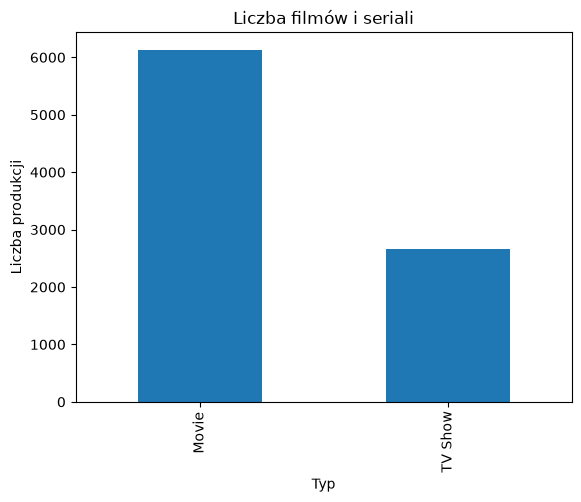

In [97]:
type_counts.plot(kind="bar")
 
plt.title("Liczba filmów i seriali")
plt.xlabel("Typ")
plt.ylabel("Liczba produkcji")
plt.show()

Wykres 2 – Kategorie wiekowe

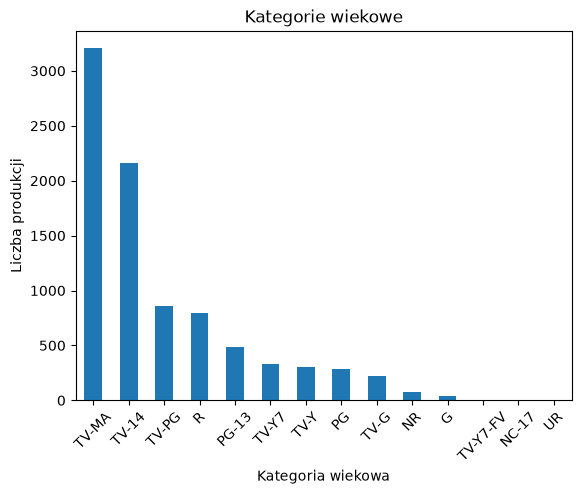

In [98]:
rating_counts.plot(kind="bar")
 
plt.title("Kategorie wiekowe")
plt.xlabel("Kategoria wiekowa")
plt.ylabel("Liczba produkcji")
plt.xticks(rotation=45)
plt.show()

Wykres 3 – Kraje przodujące pod względem ilości produkcji

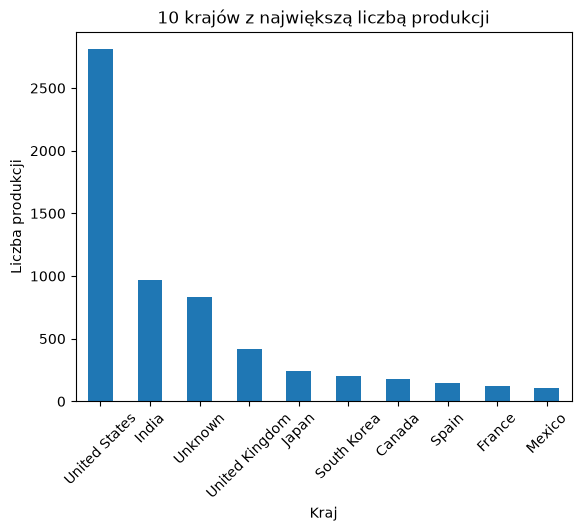

In [99]:
country_counts.plot(kind="bar")
 
plt.title("10 krajów z największą liczbą produkcji")
plt.xlabel("Kraj")
plt.ylabel("Liczba produkcji")
plt.xticks(rotation=45)
plt.show()

In [101]:
# Liczba wszystkich produkcji
all_productions = len(df)
 
# Liczba produkcji z USA
usa_productions = df["country"].str.contains("United States", na=False).sum()
 
# Obliczenie procentu
usa_percent = (usa_productions / all_productions) * 100
 
print(f"Liczba produkcji z USA: {usa_productions}")
print(f"Udział produkcji z USA: {usa_percent:.2f}%")

Liczba produkcji z USA: 3681
Udział produkcji z USA: 41.86%


Wykres 4 – Rok produkcji

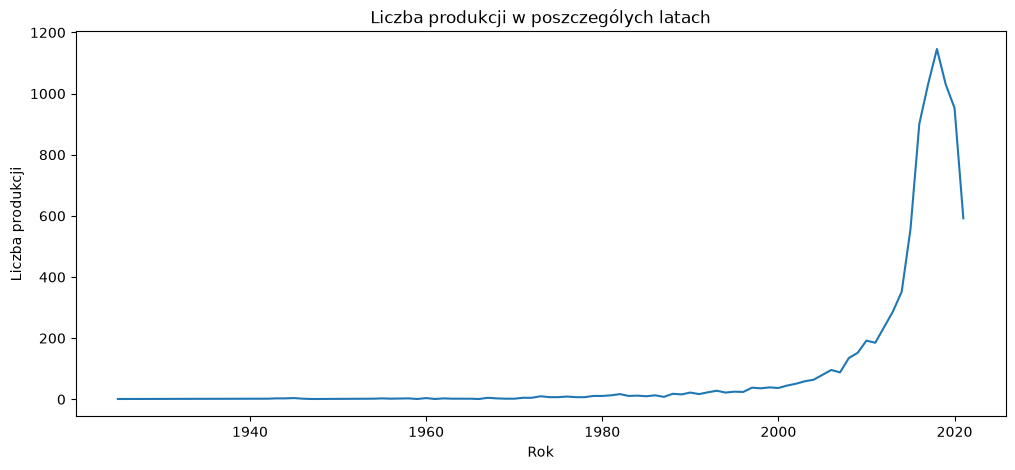

In [102]:
release_year_counts.plot(figsize=(12,5))
 
plt.title("Liczba produkcji w poszczególych latach")
plt.xlabel("Rok")
plt.ylabel("Liczba produkcji")
plt.show()

In [103]:
# Liczba wszystkich produkcji
all_productions = len(df)
 
# Liczba produkcji z 2010 roku
productions_2010 = (df["release_year"] == 2010).sum()
 
# Procent
percent_2010 = (productions_2010 / all_productions) * 100
 
print(f"Liczba produkcji z 2010 roku: {productions_2010}")
print(f"Stanowi to {percent_2010:.2f}% wszystkich produkcji.")

Liczba produkcji z 2010 roku: 192
Stanowi to 2.18% wszystkich produkcji.


In [104]:
# Produkcje od 2010 roku
productions_from_2010 = (df["release_year"] >= 2010).sum()
 
# Procent wszystkich produkcji
percent_from_2010 = (productions_from_2010 / len(df)) * 100
 
print(f"Liczba produkcji od 2010 roku: {productions_from_2010}")
print(f"Stanowi to {percent_from_2010:.2f}% wszystkich produkcji.")

Liczba produkcji od 2010 roku: 7462
Stanowi to 84.85% wszystkich produkcji.


# Podsumowanie
 
Przeprowadzono analizę zbioru danych zawierającego filmy i seriale dostępne na platformie Netflix. W ramach zadania projektowego wykonano: 
 - czyszczenie danych;
 - usunięto błędne rekordy;
 - przeprowadzono analizę opisową.

Na podstawie analizy wywnioskować można, że w zbiorze materiałów dostępnych na platformie Netflix przeważają filmy. 

Najpopularnhiejsza kategoria wiekowa udostępnianych filmów i seriali to TV-MA, czyli produkcje wyłącznie dla dorosłych. Charakteryzują się one występowaniem przemocy, wulgarnego języka, stosowania substancji niedozwolonych, obrazumące nagość i/lub treści seksualne. W Europie odpowiednikiem tej kategorii jest kategoria "+18". 

Wśród krajów pochodzenia produkcji najczęściej występują Stany Zjednoczone (41.86% wszystkich dostępnych produkcji).

Ostatni z wykresów przedstawia ilość filmów udostępnianych na platformie Netflix na podstawie roku ich produkcji. Na tej podstawie można zauważyć, że większosć dostępnych produkcji została zrealizowan po 2010 roku. Zbiór produkcji zrealizowanych po 2010 roku stanowi 84.85% wszystkich udostępnionych w serwisie produkcji.

Uzyskane wyniki pozwalają na scharakteryzowanie dostępnych na platformie Netflix produkcji, oraz obrazują strukturę samej platformy. 
 